# Representation Overlap Analysis (CKA) — v2, Delta-from-Base

**v1 result was uninformative**, not a real finding: raw hidden-state CKA saturated at 0.997-1.000 for every merge method on every task, with differences only in the 3rd-4th decimal place. The shared frozen base model dominates the mean-pooled representation so completely that a rank-16 LoRA delta barely registers — CKA had no real room to discriminate between methods. The 'late layers diverge more' pattern was also identical across GSM8K/HumanEval/Dolly (a generic depth-compounding effect, not task-specific), and the r=+0.92 GSM8K correlation was fit to 4 points differing by ~0.0005 — almost certainly noise, especially given HumanEval and Dolly showed the opposite-direction correlation.

**Fix in this version:** every representation is now `h_model - h_base` instead of `h_model` directly — isolating the adapter/merge-induced perturbation from the dominant shared base-model activation, before computing CKA. Sample count also bumped from 30 to 50 per task for more stable estimates.

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth peft
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


## Model Loading Helpers (now includes plain base model)

In [2]:
import torch
from unsloth import FastLanguageModel
from peft import PeftModel

BASE_REPO = "unsloth/Qwen3-0.6B"

def load_base(max_seq_length: int = 1024):
    """Load the plain base model with NO adapter — the reference every other
    model's representation gets subtracted against, to isolate what the
    adapter/merge actually changed."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = BASE_REPO,
        max_seq_length = max_seq_length,
        load_in_4bit   = True,
        dtype          = torch.float16,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def load_specialist(adapter_repo: str, hf_username: str = "Srishtik", max_seq_length: int = 1024):
    """Load the base model with one specialist LoRA adapter attached (not merged)."""
    base_model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = BASE_REPO,
        max_seq_length = max_seq_length,
        load_in_4bit   = True,
        dtype          = torch.float16,
    )
    model = PeftModel.from_pretrained(base_model, f"{hf_username}/{adapter_repo}")
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def load_merged(merged_repo: str, max_seq_length: int = 1024):
    """Load a fully-merged model directly (no adapter attach needed)."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = merged_repo,
        max_seq_length = max_seq_length,
        load_in_4bit   = True,
        dtype          = torch.float16,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## CKA + Representation Extraction (with delta-from-base isolation)

In [3]:
import torch

def get_layerwise_representations(model, tokenizer, prompts: list, device="cuda", max_length=512):
    """
    Runs each prompt through the model once (no generation), extracts hidden
    states at every layer (embedding output + each transformer block's output),
    mean-pools over the sequence dimension, and stacks across prompts.

    Returns a list of length n_layers+1, each a (n_prompts, hidden_dim) tensor.
    """
    model.eval()
    all_hidden = None
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_length).to(device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
        hs = out.hidden_states  # tuple: (embed_output, layer_1_output, ..., layer_N_output)
        if all_hidden is None:
            all_hidden = [[] for _ in range(len(hs))]
        for i, h in enumerate(hs):
            pooled = h[0].mean(dim=0)  # mean-pool over sequence length -> (hidden_dim,)
            all_hidden[i].append(pooled.float().cpu())
    return [torch.stack(layer_vecs, dim=0) for layer_vecs in all_hidden]


def subtract_base(raw_reps: list, base_reps: list) -> list:
    """
    Isolates the adapter/merge-induced perturbation from the (dominant, shared)
    base-model activation: returns h_model - h_base per layer.

    Without this, CKA on raw hidden states saturates near 1.0 for every method —
    confirmed empirically: linear/svd/ties/dare all showed CKA >= 0.997 against
    the matching specialist on raw hidden states, with differences only in the
    3rd-4th decimal place. The shared frozen base model dominates the mean-pooled
    representation so completely that a rank-16 LoRA delta barely registers.
    Subtracting the base model's own representation removes that dominant shared
    signal and isolates what's actually different between methods.
    """
    return [raw - base for raw, base in zip(raw_reps, base_reps)]


def linear_cka(X: torch.Tensor, Y: torch.Tensor) -> float:
    """
    Linear CKA (Kornblith et al. 2019) via Gram matrices. Invariant to
    orthogonal transformation and isotropic scaling of either representation.
    """
    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)
    K = X @ X.T
    L = Y @ Y.T
    hsic_kl = (K * L).sum()
    hsic_kk = (K * K).sum()
    hsic_ll = (L * L).sum()
    denom = (hsic_kk.sqrt() * hsic_ll.sqrt())
    if denom < 1e-8:
        # Expected at layer 0 (embedding output): LoRA never touches the
        # embedding matrix, so every model's delta-from-base is ~0 there,
        # giving a degenerate (zero-variance) representation. This nan is
        # correct and should be excluded with nan-aware aggregation
        # (np.nanmean/nanmin/nanmax) downstream, not treated as a bug to
        # silence at the source.
        return float("nan")
    return (hsic_kl / denom).item()


def layerwise_cka(reps_a: list, reps_b: list) -> list:
    """CKA at each corresponding layer between two models' representations
    on the SAME prompts."""
    assert len(reps_a) == len(reps_b), "Layer count mismatch — are these the same architecture?"
    return [linear_cka(a, b) for a, b in zip(reps_a, reps_b)]


## Build Per-Task Prompt Sets

In [4]:
from datasets import load_dataset

def build_chat_prompt(tokenizer, user_content: str) -> str:
    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
    )

def format_gsm8k_prompt(question: str) -> str:
    return (f"Solve the following math problem. Show your reasoning and put "
            f"your final numeric answer after '#### '.\n\nQuestion: {question}")

def format_humaneval_prompt(problem_prompt: str) -> str:
    return ("Complete the following Python function. Return ONLY the complete "
            "function code (including the signature), with no explanations and "
            f"no markdown formatting.\n\n{problem_prompt}")

def format_dolly_prompt(instruction: str, context: str) -> str:
    if context:
        return f"Instruction: {instruction}\nContext: {context}\nResponse:"
    return f"Instruction: {instruction}\nResponse:"


N_SAMPLES_PER_TASK = 50  # bumped from 30 — more stable CKA estimates, still cheap (single forward pass, no generation)

def build_gsm8k_prompts(tokenizer, n=N_SAMPLES_PER_TASK):
    ds = load_dataset("gsm8k", "main", split="test").select(range(n))
    return [build_chat_prompt(tokenizer, format_gsm8k_prompt(q)) for q in ds["question"]]

def build_humaneval_prompts(tokenizer, n=N_SAMPLES_PER_TASK):
    ds = load_dataset("openai/openai_humaneval", split="test").select(range(n))
    return [build_chat_prompt(tokenizer, format_humaneval_prompt(p)) for p in ds["prompt"]]

def build_dolly_prompts(tokenizer, n=N_SAMPLES_PER_TASK):
    ds = load_dataset("databricks/databricks-dolly-15k", split="train").shuffle(seed=42).select(range(n))
    return [build_chat_prompt(tokenizer, format_dolly_prompt(ex["instruction"], ex.get("context", "")))
            for ex in ds]

print(f"Prompt sets will use n={N_SAMPLES_PER_TASK} samples per task.")


Prompt sets will use n=50 samples per task.


## Base Model Reference Representations (NEW)

Computed once per task — every specialist and merged model's representation gets this subtracted out before CKA.

In [5]:
import gc

print(f"{'='*60}\nBase model reference (no adapter)\n{'='*60}")
base_model, base_tokenizer = load_base()

task_prompts = {
    "gsm8k"    : build_gsm8k_prompts(base_tokenizer),
    "humaneval": build_humaneval_prompts(base_tokenizer),
    "dolly"    : build_dolly_prompts(base_tokenizer),
}

base_reps_per_task = {}
for task, prompts in task_prompts.items():
    base_reps_per_task[task] = get_layerwise_representations(base_model, base_tokenizer, prompts)
    print(f"  {task:<12} base reps: {len(base_reps_per_task[task])} layers x "
          f"{base_reps_per_task[task][0].shape[0]} prompts")

del base_model
gc.collect()
torch.cuda.empty_cache()
print("\nBase model reference representations ready.")


Base model reference (no adapter)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

  gsm8k        base reps: 29 layers x 50 prompts
  humaneval    base reps: 29 layers x 50 prompts
  dolly        base reps: 29 layers x 50 prompts

Base model reference representations ready.


## Specialist Delta Representations

In [6]:
import gc

specialists = {
    "gsm8k"    : {"adapter_repo": "qwen3-trained-on-metamath-15k"},
    "humaneval": {"adapter_repo": "qwen3-trained-on-code-alpaca-18k"},
    "dolly"    : {"adapter_repo": "qwen3-trained-on-dolly-15k"},
}

task_to_specialist_name = {"gsm8k": "metamath", "humaneval": "codealpaca", "dolly": "dolly"}

specialist_delta_reps = {}   # task -> list of per-layer DELTA (n_prompts, hidden_dim) tensors

for task, cfg in specialists.items():
    print(f"\n{'='*60}\nSpecialist reference: {task} ({cfg['adapter_repo']})\n{'='*60}")
    model, tokenizer = load_specialist(cfg["adapter_repo"])
    raw_reps = get_layerwise_representations(model, tokenizer, task_prompts[task])
    specialist_delta_reps[task] = subtract_base(raw_reps, base_reps_per_task[task])
    mean_delta_norm = sum(d.norm(dim=1).mean().item() for d in specialist_delta_reps[task]) / len(specialist_delta_reps[task])
    print(f"  {len(specialist_delta_reps[task])} layers x {specialist_delta_reps[task][0].shape[0]} prompts  "
          f"(mean per-layer delta norm: {mean_delta_norm:.4f})")
    del model
    gc.collect()
    torch.cuda.empty_cache()

print("\nSpecialist DELTA representations ready.")



Specialist reference: gsm8k (qwen3-trained-on-metamath-15k)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

  29 layers x 50 prompts  (mean per-layer delta norm: 13.0803)

Specialist reference: humaneval (qwen3-trained-on-code-alpaca-18k)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


...

  29 layers x 50 prompts  (mean per-layer delta norm: 18.7206)

Specialist reference: dolly (qwen3-trained-on-dolly-15k)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

  29 layers x 50 prompts  (mean per-layer delta norm: 14.1744)

Specialist DELTA representations ready.


## Merged Model Delta Representations + CKA

Update `merged_repos` below with your actual repo names if any have changed.

In [7]:
import gc
import numpy as np

merged_repos = {
    "linear" : "Srishtik/Qwen3-0.6B-linear-3-adapters-merged-2",
    "svd"    : "Srishtik/Qwen3-0.6B-svd-3-adapters-merged-2",
    "ties"   : "Srishtik/Qwen3-0.6B-ties-3-adapters-merged-2",
    "dare"   : "Srishtik/Qwen3-0.6B-dare-3-adapters-merged-2",
    "slerp"  : "Srishtik/Qwen3-0.6B-slerp-FIXED-3-adapters-merged-2",  # re-enabled -- confirm this repo is the fixed geometric-mean checkpoint before running
}

results = {}  # results[method][task] = list of per-layer CKA scores (on DELTA representations)

for method_name, repo in merged_repos.items():
    print(f"\n{'='*60}\nMerged model: {method_name} ({repo})\n{'='*60}")
    model, tokenizer = load_merged(repo)
    results[method_name] = {}
    for task, prompts in task_prompts.items():
        raw_reps   = get_layerwise_representations(model, tokenizer, prompts)
        delta_reps = subtract_base(raw_reps, base_reps_per_task[task])
        cka_scores = layerwise_cka(specialist_delta_reps[task], delta_reps)
        results[method_name][task] = cka_scores
        # nan-aware: layer 0 (embedding) is expected to be nan since LoRA
        # never touches the embedding matrix -- exclude it here rather than
        # letting it poison the whole-model summary stats.
        valid = np.array([s for s in cka_scores if not np.isnan(s)])
        mean_cka = valid.mean()
        print(f"  {task:<12} (vs {task_to_specialist_name[task]:<10} specialist)  mean CKA={mean_cka:.4f}  "
              f"min={valid.min():.4f}  max={valid.max():.4f}  "
              f"(excluded {len(cka_scores) - len(valid)} nan layer(s))")
    del model
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll merged models processed (CKA computed on delta representations).")



Merged model: linear (Srishtik/Qwen3-0.6B-linear-3-adapters-merged-2)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9050  min=0.7946  max=0.9594  (excluded 1 nan layer(s))
  humaneval    (vs codealpaca specialist)  mean CKA=0.8763  min=0.6609  max=0.9733  (excluded 1 nan layer(s))
  dolly        (vs dolly      specialist)  mean CKA=0.9802  min=0.9567  max=0.9980  (excluded 1 nan layer(s))

Merged model: svd (Srishtik/Qwen3-0.6B-svd-3-adapters-merged-2)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9072  min=0.7967  max=0.9590  (excluded 1 nan layer(s))
  humaneval    (vs codealpaca specialist)  mean CKA=0.8790  min=0.6677  max=0.9729  (excluded 1 nan layer(s))
  dolly        (vs dolly      specialist)  mean CKA=0.9787  min=0.9572  max=0.9978  (excluded 1 nan layer(s))

Merged model: ties (Srishtik/Qwen3-0.6B-ties-3-adapters-merged-2)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


...

  gsm8k        (vs metamath   specialist)  mean CKA=0.9190  min=0.8618  max=0.9603  (excluded 1 nan layer(s))
  humaneval    (vs codealpaca specialist)  mean CKA=0.9055  min=0.7303  max=0.9773  (excluded 1 nan layer(s))
  dolly        (vs dolly      specialist)  mean CKA=0.9837  min=0.9658  max=0.9983  (excluded 1 nan layer(s))

Merged model: dare (Srishtik/Qwen3-0.6B-dare-3-adapters-merged-2)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9243  min=0.8702  max=0.9595  (excluded 1 nan layer(s))
  humaneval    (vs codealpaca specialist)  mean CKA=0.9162  min=0.7934  max=0.9780  (excluded 1 nan layer(s))
  dolly        (vs dolly      specialist)  mean CKA=0.9852  min=0.9734  max=0.9979  (excluded 1 nan layer(s))

Merged model: slerp (Srishtik/Qwen3-0.6B-slerp-FIXED-3-adapters-merged-2)
==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9202  min=0.8680  max=0.9623  (excluded 1 nan layer(s))
  humaneval    (vs codealpaca specialist)  mean CKA=0.8844  min=0.7217  max=0.9752  (excluded 1 nan layer(s))
  dolly        (vs dolly      specialist)  mean CKA=0.9864  min=0.9689  max=0.9996  (excluded 1 nan layer(s))

All merged models processed (CKA computed on delta representations).


## Visualization

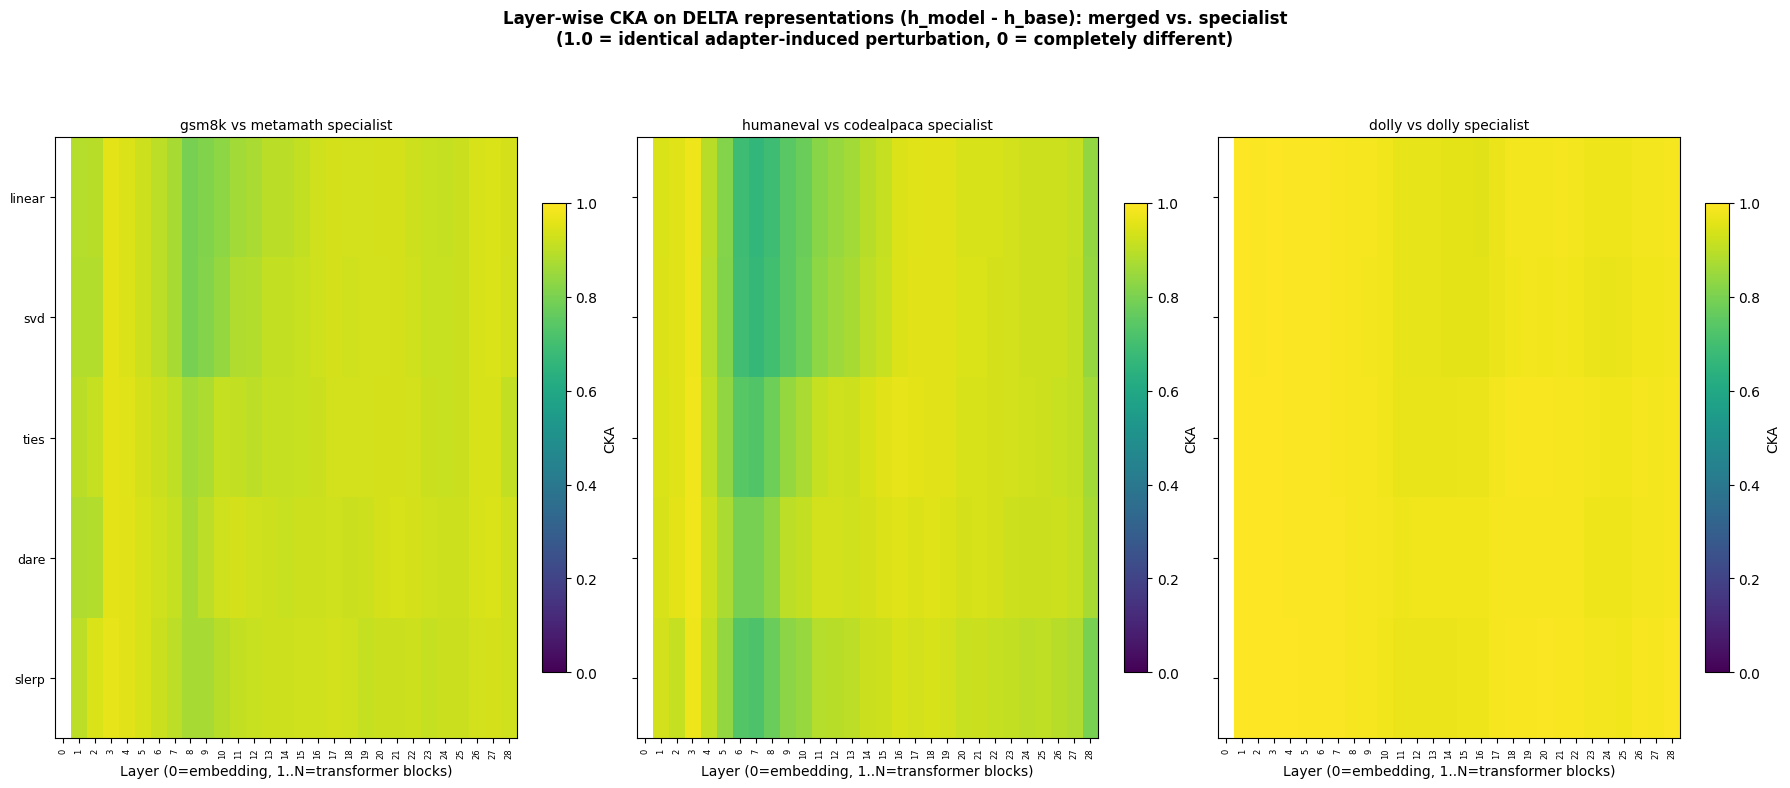

Saved: cka_layerwise_heatmap.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

tasks = list(task_prompts.keys())
methods = list(results.keys())
n_layers = len(next(iter(results.values()))[tasks[0]])

fig, axes = plt.subplots(1, len(tasks), figsize=(6 * len(tasks), 8), sharey=True)
if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    matrix = np.array([results[m][task] for m in methods])  # (n_methods, n_layers)
    im = ax.imshow(matrix, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(n_layers))
    ax.set_xticklabels(range(n_layers), fontsize=6, rotation=90)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods, fontsize=9)
    ax.set_xlabel("Layer (0=embedding, 1..N=transformer blocks)")
    ax.set_title(f"{task} vs {task_to_specialist_name[task]} specialist", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, label="CKA")

fig.suptitle("Layer-wise CKA on DELTA representations (h_model - h_base): merged vs. specialist\n"
             "(1.0 = identical adapter-induced perturbation, 0 = completely different)", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("cka_layerwise_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cka_layerwise_heatmap.png")


## Does Layer-Depth CKA Predict Downstream Performance?

Same analysis as v1, now on delta-based CKA values — check whether the CKA values actually spread out enough this time to make this correlation meaningful.

In [9]:
import numpy as np

# Known scores from prior evaluation runs (n=200 GSM8K/Dolly, n=164 HumanEval)
known_scores = {
    "linear": {"gsm8k": 0.1100, "humaneval": 0.2012, "dolly": 17.8096},   # dolly = perplexity (lower better)
    "svd"   : {"gsm8k": 0.1550, "humaneval": 0.2073, "dolly": 20.5070},
    "ties"  : {"gsm8k": 0.0550, "humaneval": 0.2073, "dolly": 16.7428},
    "dare"  : {"gsm8k": 0.0400, "humaneval": 0.2378, "dolly": 17.2781},
    # "slerp": {"gsm8k": ..., "humaneval": ..., "dolly": ...},  # fill in once you have eval numbers for the re-enabled slerp checkpoint
}

# ── Bin layers into early/mid/late thirds and compare mean CKA per bin ──
bin_edges = np.linspace(0, n_layers, 4).astype(int)  # 3 bins
bin_names = ["early", "mid", "late"]
bin_ranges = list(zip(bin_edges[:-1], bin_edges[1:]))

print(f"Layer bins: {dict(zip(bin_names, bin_ranges))}\n")

for task in tasks:
    print(f"{'='*70}\n{task} (vs {task_to_specialist_name[task]} specialist)\n{'='*70}")
    print(f"{'Method':<10}{'early CKA':>12}{'mid CKA':>12}{'late CKA':>12}{'downstream score':>18}")
    for method in methods:
        if method not in known_scores:
            continue
        scores = results[method][task]
        bin_means = [np.nanmean(scores[lo:hi]) for lo, hi in bin_ranges]  # nan-aware: layer 0 is always nan (embedding untouched by LoRA)
        score_key = task if task in known_scores[method] else task
        downstream = known_scores[method].get(task, float("nan"))
        print(f"{method:<10}{bin_means[0]:>12.4f}{bin_means[1]:>12.4f}{bin_means[2]:>12.4f}{downstream:>18.4f}")
    print()

# ── Simple correlation check: mean CKA (whole model) vs downstream score, per task ──
print(f"{'='*70}")
print("Correlation check (exploratory — only as many points as methods tested,")
print("not a statistically robust sample size on its own):")
print(f"{'='*70}")
for task in tasks:
    x, y = [], []
    for method in methods:
        if method not in known_scores:
            continue
        mean_cka = np.nanmean(results[method][task])  # nan-aware: excludes the expected layer-0 nan
        x.append(mean_cka)
        y.append(known_scores[method][task])
    if len(x) >= 3:
        corr = np.corrcoef(x, y)[0, 1]
        direction = "expected (higher CKA -> better score)" if (task != "dolly" and corr > 0) or (task == "dolly" and corr < 0) else "OPPOSITE of expected direction"
        print(f"  {task:<12} mean-CKA vs downstream-score correlation: r={corr:+.3f}  ({direction})")
    else:
        print(f"  {task:<12} not enough methods with known scores to correlate")


Layer bins: {'early': (np.int64(0), np.int64(9)), 'mid': (np.int64(9), np.int64(19)), 'late': (np.int64(19), np.int64(29))}

gsm8k (vs metamath specialist)
Method       early CKA     mid CKA    late CKA  downstream score
linear          0.8971      0.8872      0.9292            0.1100
svd             0.8959      0.8945      0.9289            0.1550
ties            0.9172      0.9118      0.9277            0.0550
dare            0.9164      0.9226      0.9323            0.0400

humaneval (vs codealpaca specialist)
Method       early CKA     mid CKA    late CKA  downstream score
linear          0.8264      0.8702      0.9225            0.2012
svd             0.8290      0.8751      0.9231            0.2073
ties            0.8577      0.9246      0.9245            0.2073
dare            0.8866      0.9329      0.9232            0.2378

dolly (vs dolly specialist)
Method       early CKA     mid CKA    late CKA  downstream score
linear          0.9944      0.9676      0.9814           17.80